In [1]:
import pandas as pd
import numpy as np
import json
import sqlite3
from tqdm.notebook import tqdm
import rapidfuzz
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

## Hiski

In [2]:
files = (
    "data/hiski-2026-09-22-cnv/ammhaud.cnv",
    "data/hiski-2026-09-22-cnv/ammkasta.cnv",
    "data/hiski-2026-09-22-cnv/ammkasti.cnv",
    "data/hiski-2026-09-22-cnv/ammkastk.cnv",
    "data/hiski-2026-09-22-cnv/ammmuutt.cnv",
    "data/hiski-2026-09-22-cnv/ammom.cnv",
    "data/hiski-2026-09-22-cnv/ammvihi.cnv",
    "data/hiski-2026-09-22-cnv/ammvihv.cnv"
)

In [3]:
files_read = []
for file in files:
    with open(file, "r") as fp:
        files_read += [row.strip().split("@") for row in fp.readlines()]

In [4]:
connection = sqlite3.connect("data/all_hiski_records.sqlite3")
cursor = connection.cursor()

In [5]:
occupations_flat = set()
for f in files_read:
    occupations_flat.update(f)

In [6]:
cursor.execute(
    "SELECT * FROM burial;"
)
burials = cursor.fetchall()

## Counting occupation names

In [7]:
column_to_idx = {
    c[1]: c[0] for c in cursor.execute("PRAGMA table_info(burial);").fetchall()
}
column_to_idx

{'event_id': 0,
 'death_day': 1,
 'death_month': 2,
 'death_year': 3,
 'burial_day': 4,
 'burial_month': 5,
 'burial_year': 6,
 'village': 7,
 'house': 8,
 'profession': 9,
 'first_name': 10,
 'patronym': 11,
 'last_name': 12,
 'death_cause': 13,
 'age_years': 14,
 'age_months': 15,
 'age_weeks': 16,
 'age_days': 17,
 'etc': 18,
 'village_id': 19,
 'parish_id': 20,
 'professionN': 21,
 'first_nameN': 22,
 'patronymN': 23,
 'last_nameN': 24,
 'death_causeN': 25}

In [8]:
for i, b in tqdm(enumerate(burials), total=len(burials)):
    fixed = tuple(
        map(
            lambda x: (
                x if not isinstance(x, str) else x.split("\\")[0].strip()
            ),
            b,
        )
    )
    burials[i] = tuple(
        map(
            lambda x: int(x) if isinstance(x, str) and x.isnumeric() else x,
            fixed,
        )
    )

  0%|          | 0/3289363 [00:00<?, ?it/s]

In [9]:
burials = list(
    filter(
        lambda x: (
            isinstance(x[14], int)
        ) and (
            x[14] >= 0
        ) and (
            x[14] <= 120
        ) and (
            x[13] != ""
        ),
        burials)
)

In [10]:
occupation_counter = Counter()
death_cause_counter = Counter()

occupation_counter.update([person[9] for person in burials])
death_cause_counter.update([person[13] for person in burials])

In [11]:
occupation_counter.most_common(50)

[('', 382205),
 ('b.', 145331),
 ('b:', 47865),
 ('barn', 42430),
 ('son', 39728),
 ('s.', 36993),
 ('d:r', 30456),
 ('dr.', 21023),
 ('Inh.', 20477),
 ('Bd.', 16455),
 ('s:', 14490),
 ('B.', 13401),
 ('dr', 12918),
 ('Son', 12140),
 ('h:u', 10950),
 ('Bonde', 10794),
 ('Bd.s.', 9609),
 ('Bd.b.', 9293),
 ('Bd:b:', 8355),
 ('Torp.', 7904),
 ('D:r', 7854),
 ('b: b:', 7763),
 ('B.b.', 7584),
 ('B.s.', 7394),
 ('Barn', 7321),
 ('Drg.', 6849),
 ('b', 6739),
 ('dr:', 6598),
 ('lapsi', 6411),
 ('B:', 6363),
 ('inh.', 6037),
 ('Tp.', 5788),
 ('l.', 5559),
 ('kind', 5325),
 ('d:', 5265),
 ('Inh:', 5018),
 ('Inh.b.', 4941),
 ('h.', 4891),
 ('Pig.', 4773),
 ('Bondeson', 4589),
 ('Torpare', 4423),
 ('dotter', 4191),
 ('Trp.', 3969),
 ('hu:', 3826),
 ('Tal.', 3778),
 ('hu', 3612),
 ('bd.s.', 3612),
 ('Bd. b.', 3585),
 ('e:a', 3577),
 ('b.b.', 3514)]

Text(0.5, 1.0, 'Bd.s.')

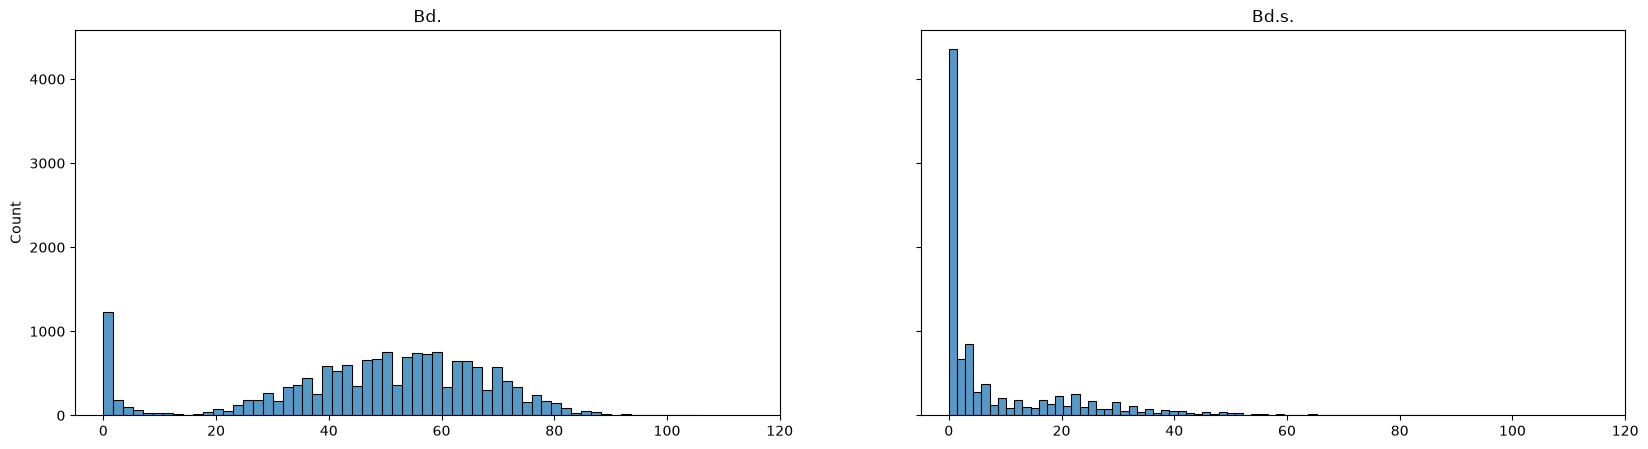

In [12]:
a = "Bd."
b = "Bd.s."
column_idx = column_to_idx["profession"]
fig, axs = plt.subplots(1, 2, figsize=(20, 5), sharey=True)
sns.histplot(
    [
        b[column_to_idx["age_years"]]
        for b in tuple(filter(lambda x: x[column_idx] == a, burials))
    ],
    ax=axs[0],
    bins=60
)
sns.histplot(
    [
        b[column_to_idx["age_years"]]
        for b in tuple(filter(lambda x: x[column_idx] == b, burials))
    ],
    ax=axs[1],
    bins=60
)

axs[0].set_xlim(-5, 120)
axs[1].set_xlim(-5, 120)

axs[0].set_title(a)
axs[1].set_title(b)

In [13]:
death_cause_counter.most_common(50)

[('koppor', 87403),
 ('styng', 70244),
 ('lungsot', 68792),
 ('feber', 67079),
 ('rödsot', 66432),
 ('slag', 49540),
 ('hosta', 44474),
 ('oang.', 37887),
 ('kikhosta', 35318),
 ('ålderd.', 29022),
 ('Lungsot', 25758),
 ('ok.sj.', 23465),
 ('Koppor', 22540),
 ('ålderdom', 21561),
 ('Feber', 21308),
 ('Rödsot', 19785),
 ('okänd', 19576),
 ('kikh.', 17866),
 ('Styng', 17378),
 ('Slag', 17280),
 ('-', 16982),
 ('vattsot', 16663),
 ('messling', 16449),
 ('oang.sj.', 15830),
 ('Kikhosta', 15397),
 ('oang:', 15189),
 ('ålder', 15089),
 ('vattusot', 14882),
 ('stygn', 14798),
 ('ok.b.sj.', 13725),
 ('tvinsot', 13652),
 ('magref', 13204),
 ('Ålderdom', 12048),
 ('Hosta', 11948),
 ('hets.feb.', 11592),
 ('oangifven', 10938),
 ('lungs.', 10923),
 ('andtäppa', 10558),
 ('oang. sj.', 9566),
 ('messl.', 9442),
 ('Oang.', 9395),
 ('dödf.', 9169),
 ('svullnad', 8293),
 ('svulnad', 7922),
 ('rötfeber', 7839),
 ('Messling', 7779),
 ('Nerffeber', 7452),
 ('vatusot', 7169),
 ('lifsjuka', 7131),
 ('nerffe